# Analise de dados

In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---
Leitura do CSV

In [102]:
df = pd.read_csv('query1.csv',sep=',', encoding='cp1252', decimal='.', thousands=',')

Leitura da colunas

In [103]:
df.head()

,DEPARTMENT_NAME,JOB_ID,AVG(E.SALARY),MAX(E.SALARY),MIN(E.SALARY)
0,Accounting,AC_ACCOUNT,8300.0,8300,8300
1,Accounting,AC_MGR,12008.0,12008,12008
2,Administration,AD_ASST,4400.0,4400,4400
3,Executive,AD_PRES,24000.0,24000,24000
4,Executive,AD_VP,17000.0,17000,17000


In [104]:
df.info()
# 19 linhas, 5 colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DEPARTMENT_NAME  19 non-null     object 
 1   JOB_ID           19 non-null     object 
 2   AVG(E.SALARY)    19 non-null     float64
 3   MAX(E.SALARY)    19 non-null     int64  
 4   MIN(E.SALARY)    19 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 892.0+ bytes


In [105]:
df.isnull().sum()

DEPARTMENT_NAME    0
JOB_ID             0
AVG(E.SALARY)      0
MAX(E.SALARY)      0
MIN(E.SALARY)      0
dtype: int64

In [106]:
df.duplicated().sum()
print("Número de linhas duplicadas:", df.duplicated().sum())

Número de linhas duplicadas: 0


In [107]:
sns.set_theme(style="whitegrid") # serve para definir o estilo do gráfico, nesse caso, grid branco (sao as linhas de grade do gráfico)

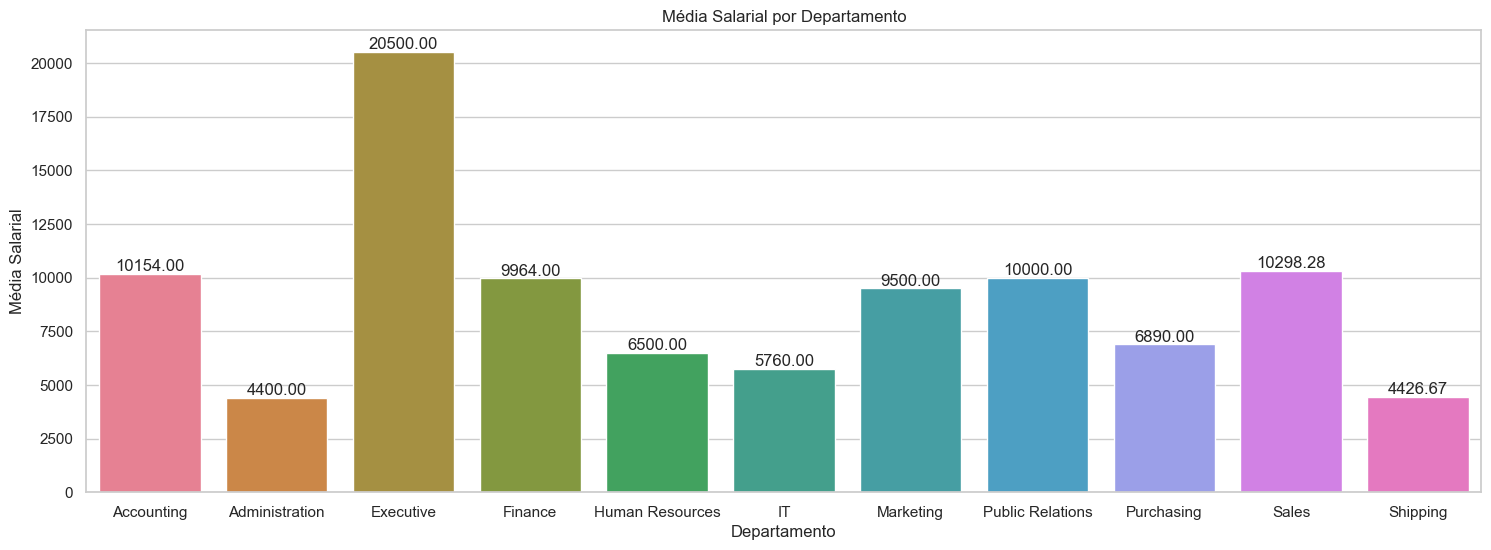

In [108]:
plt.figure(figsize=(18, 6))
ax =sns.barplot(
    data=df,
    x='DEPARTMENT_NAME',
    y="AVG(E.SALARY)",
    hue='DEPARTMENT_NAME',
    errorbar=None,
)
plt.title('Média Salarial por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Média Salarial')

# Adicionando os rótulos de dados
# transforma o grafico em uma variavel para poder adicionar os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')
plt.show()

# Leitura da segunda base de dados

In [109]:
df = pd.read_csv('query2.csv',sep=',', encoding='cp1252', decimal='.', thousands=',')

In [110]:
data2 = df

In [111]:
data2.head()

,MEDIA_SALARIAL,MAXIMO_SALARIO,MINIMO_SALARIO,QTD_FUNCIONARIO,REGION_NAME,CITY
0,8845.33,24000,2500,18,Americas,Seattle
1,3475.56,8200,2100,45,Americas,South San Francisco
2,5760.00,9000,4200,5,Americas,Southlake
3,9500.00,13000,6000,2,Americas,Toronto
4,6500.00,6500,6500,1,Europe,London


In [112]:
data2['QTD_FUNCIONARIO'].describe() # as outras colunas ja foram feitas no sql, entao nao precisa fazer aqui


count     8.000000
mean     13.375000
std      17.344719
min       1.000000
25%       1.000000
50%       3.500000
75%      22.000000
max      45.000000
Name: QTD_FUNCIONARIO, dtype: float64

In [113]:
data2.isnull().sum()

MEDIA_SALARIAL     0
MAXIMO_SALARIO     0
MINIMO_SALARIO     0
QTD_FUNCIONARIO    0
REGION_NAME        1
CITY               1
dtype: int64

In [114]:
# Remove todas as linhas que tenham pelo menos um valor nulo
data2_sem_nulos = data2.dropna()

# Se quiser sobrescrever o próprio DataFrame
data2.dropna(inplace=True)


In [115]:
data2.duplicated().sum()
print("Número de linhas duplicadas:", data2.duplicated().sum())

Número de linhas duplicadas: 0


# Gráfico de Quantidade de Funcionários por continente

In [116]:
sns.set_theme(style="whitegrid")

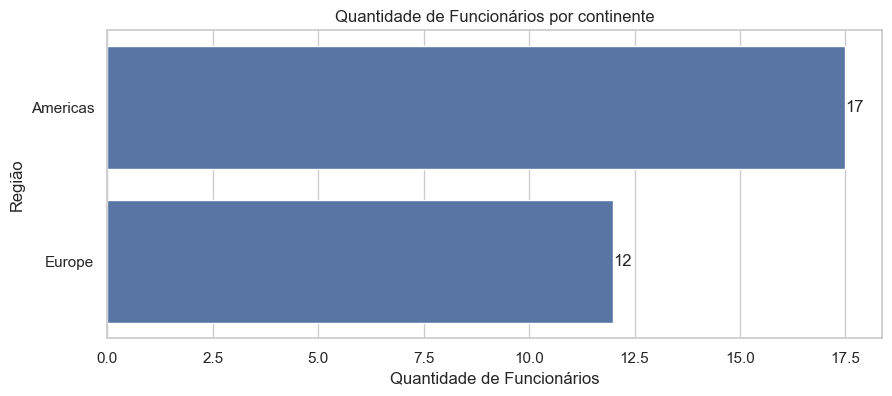

In [117]:
plt.figure(figsize=(10, 4))
axx = sns.barplot(
    data=data2,
    x='QTD_FUNCIONARIO',
    y='REGION_NAME',
    errorbar=None
)

plt.title('Quantidade de Funcionários por continente')
plt.xlabel('Quantidade de Funcionários')
plt.ylabel('Região')

# Adicionando rótulos em cada barra
for container in axx.containers:
    axx.bar_label(container, fmt='%d', label_type='edge')

plt.show()


# Gráfico de Média Salárial por Continente

In [118]:
sns.set_theme(style="whitegrid")

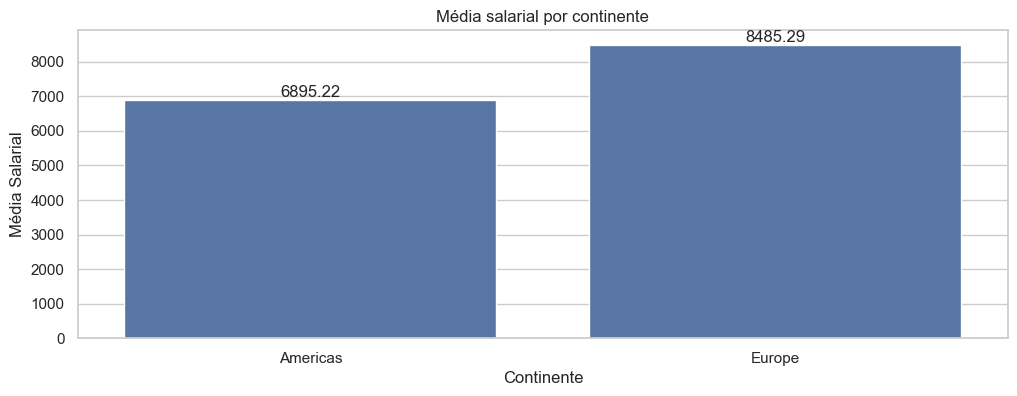

In [119]:
plt.figure(figsize=(12, 4))
ax = sns.barplot(
    data=data2,
    x='REGION_NAME',
    y='MEDIA_SALARIAL',
    errorbar=None
)
plt.title('Média salarial por continente')
plt.xlabel('Continente')
plt.ylabel('Média Salarial')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')

plt.show()

# Grafico Quantidade de funcionários por cidade da América

In [120]:
sns.set_theme(style="whitegrid")

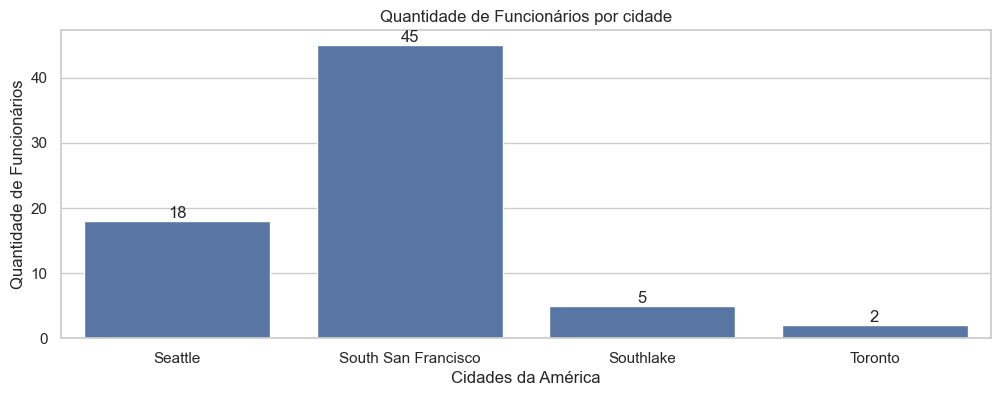

In [121]:
# Filtrar apenas registros da América
data_america = data2[data2['REGION_NAME'] == 'Americas']

plt.figure(figsize=(12, 4))
ax = sns.barplot(
    data=data_america, # fique atento para trocar o data2 por data_america
    x='CITY',
    y='QTD_FUNCIONARIO',
    errorbar=None
)
plt.title('Quantidade de Funcionários por cidade')
plt.xlabel('Cidades da América')
plt.ylabel('Quantidade de Funcionários')

# Adicionando rótulos em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()


# Grafico Quantidade de funcionários por cidade da Europa

In [122]:
sns.set_theme(style="whitegrid")

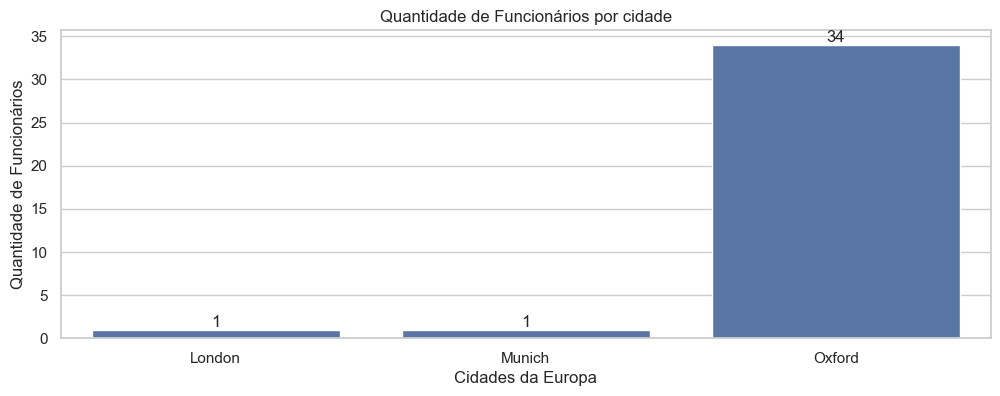

In [123]:
# Filtrar apenas registros da Europa
data_europa = data2[data2['REGION_NAME'] == 'Europe']

plt.figure(figsize=(12, 4))
ax = sns.barplot(
    data=data_europa, # fique atento para trocar o data2 por data_europa
    x='CITY',
    y='QTD_FUNCIONARIO',
    errorbar=None
)
plt.title('Quantidade de Funcionários por cidade')
plt.xlabel('Cidades da Europa')
plt.ylabel('Quantidade de Funcionários')

# Adicionando rótulos em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()
